In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Analyst data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

Customizing our chart from 12_Exercise_Trending_Skills.ipynb

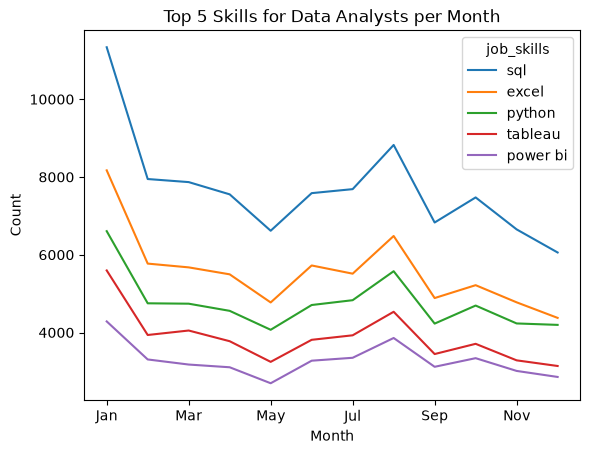

In [5]:
# Create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job skills column and pivot
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

# Sort the skills by total count (descending)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# ---- CORRECTED SECTION ----
# Reset index to make month numbers a column
df_DA_pivot = df_DA_pivot.reset_index()

# Convert month number to month name (e.g., 1 -> 'Jan')
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')  # ← '%b' gives short month name
)

# Set month name as index and drop the numeric month column
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Plot the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

# Corrected axis labels
plt.title('Top 5 Skills for Data Analysts per Month')
plt.xlabel('Month')          # X‑axis should be months, not Count
plt.ylabel('Count')          # Y‑axis is the count
plt.show()

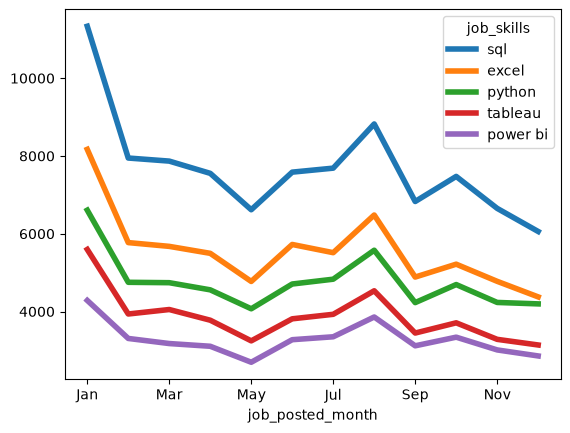

In [6]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4
)

plt.show()

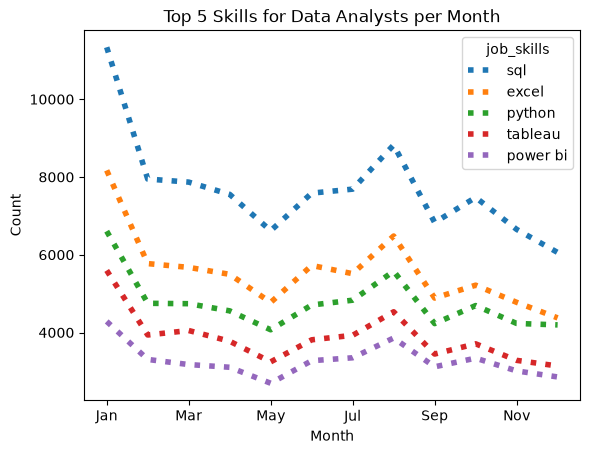

In [7]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':'        # Dotted line
)
plt.title('Top 5 Skills for Data Analysts per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

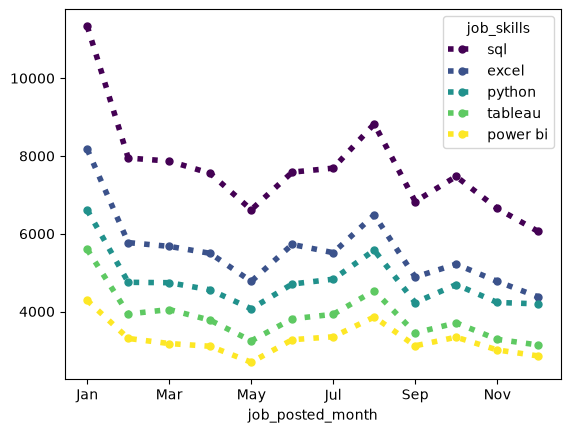

In [8]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', # options: '-', '--', '--.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    marker='o', # options: 'o', 'x', '+', '*', 's', '.', ',', '1', '2', '3', '4', ...
    markersize=5
)

plt.show()

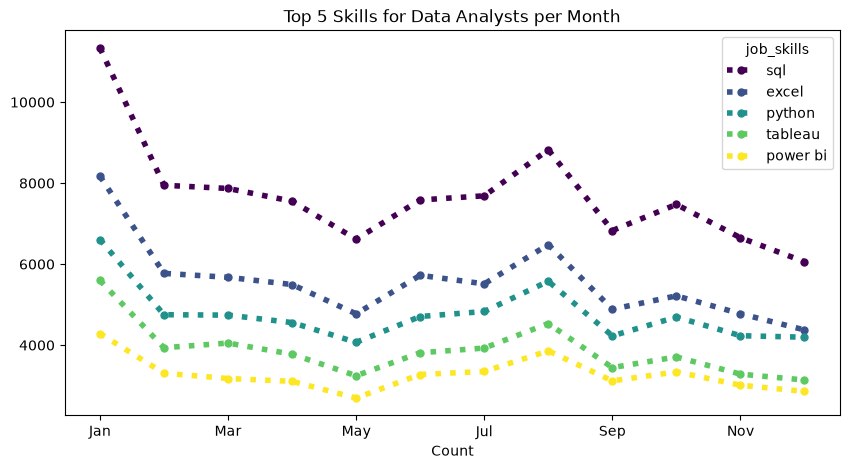

In [9]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', # options: '-', '--', '--.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    marker='o', # options: 'o', 'x', '+', '*', 's', '.', ',', '1', '2', '3', '4', ...
    markersize=5,
    figsize=(10,5)
)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.xlabel('Count')
plt.ylabel('')
plt.show()
plt.show()

Customizing our Scatter plot from 15_Scatter_Plot.ipynb

In [10]:
# Explode the 'job_skills' into individual rows
df_exploded = df_DA.explode('job_skills')

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)
skill_stats

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


In [11]:
!pip install adjustText

In [12]:
from adjustText import adjust_text

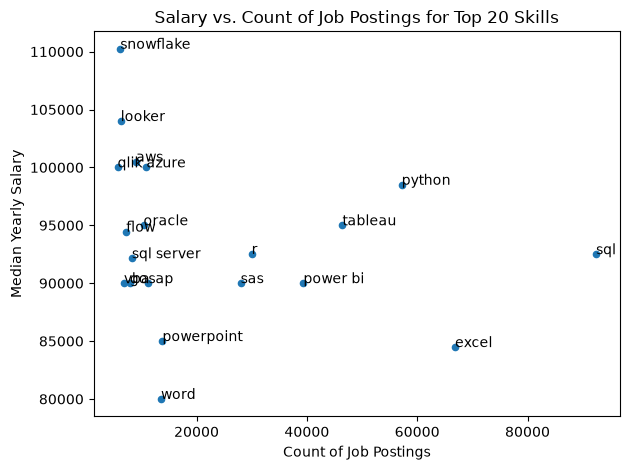

In [13]:
from adjustText import adjust_text
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

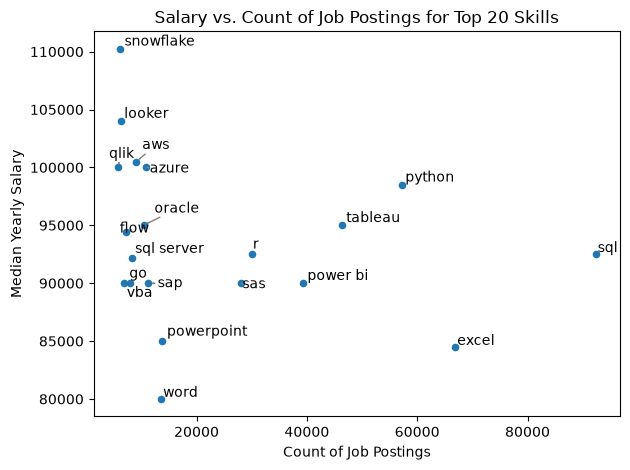

In [18]:

from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts,arrowprops=dict(arrowstyle="->", color='gray', lw=1))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

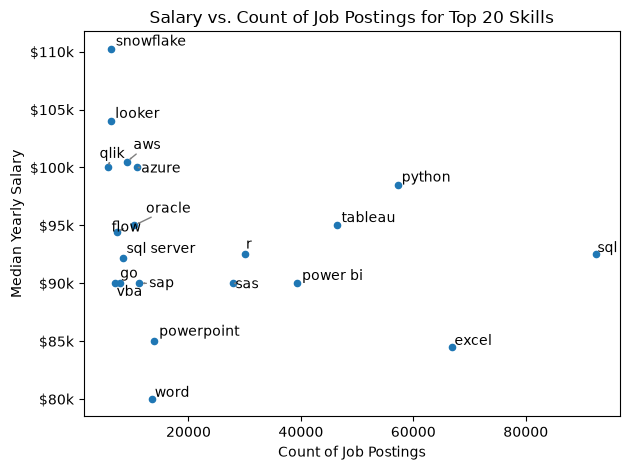

In [25]:
# fig, ax = plt.subplots()


skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))

# Set axis labels, title, and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()